<a href="https://colab.research.google.com/github/azholl/lis5693/blob/main/lab-6/lab-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing and importing libraries

In [3]:
!pip install textnets

In [4]:
import textnets as tn

Fixing the initial seed for the pseudorandom number generator

In [5]:
tn.params

Parameter              Value         
--------------------   --------------
seed                   4277          
autodownload           False         
figsize                (16, 9)       
lang                   en_core_web_sm
progress_bar           True          
resolution_parameter   0.1           
tuning_parameter       0.5

Helps ensure reproducibility

In [6]:
tn.params["seed"] = 42

Preparing corpus by importing data and saving as df and using tn.Corpus(df["Abstract"]) to pull in just the abstract, since that's the column I focused on in the last lab.

In [7]:
import requests
import io

url = "https://raw.githubusercontent.com/azholl/lis5693/main/lab-6/lab-6-data.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

import pandas as pd

df = pd.read_csv(io.StringIO(text))
df.head()

,Lens ID,Title,Publication Year,Author/s,Abstract,Keywords
0,000-425-845-807-513,Coping with long-COVID stigma: The role of sel...,2025,Maor Shani; Kilian Wübbelt,Long COVID has been associated with stigmatiza...,NaN
1,000-516-474-169-658,Age and chest computed tomography severity sco...,2024,Merve Erkan,"<AbstractText Label=""INTRODUCTION"">About one-t...",chest CT; long-COVID; pneumonia chest CT sever...
2,000-521-509-636-014,To Long COVID and Beyond,2021,David Misselbrook,David Misselbrook ; ; ; ; New diseases don’t c...,NaN
3,000-579-570-485-747,Children with Long Covid: Co-producing a speci...,2021,Michael Fanner; Elaine Maxwell,"<jats:p>Globally, children have been profoundl...",NaN
4,001-093-041-546-993,"Evaluating the associations among asthma, asth...",2025,Chun-Tse Hung; Yu-Chien Hung; Chi-Won Suk; Chu...,"<AbstractText Label=""OBJECTIVE"" NlmCategory=""O...",Asthma; Asthma control; COVID-19; Long COVID; ...


In [8]:
corpus = tn.Corpus(df["Abstract"], lang="en")

In [9]:
corpus

<Corpus with 20 documents using language model 'en_core_web_sm'>

Create network, had to add mini_docs=3 (instead of 1) to drop terms that only appear in 1 document, and remove_weak_edges=True because my clusters were unreadable with how many terms and edges there were.

In [10]:
t = tn.Textnet(corpus.tokenized(), min_docs=3, remove_weak_edges=True)
t

0docs [00:00, ?docs/s]

Textnet,Docs: 20,Terms: 144,Edges: 622


There are 144 terms and 622 edges in my dataset after cleaning it up

Visualize and analyze

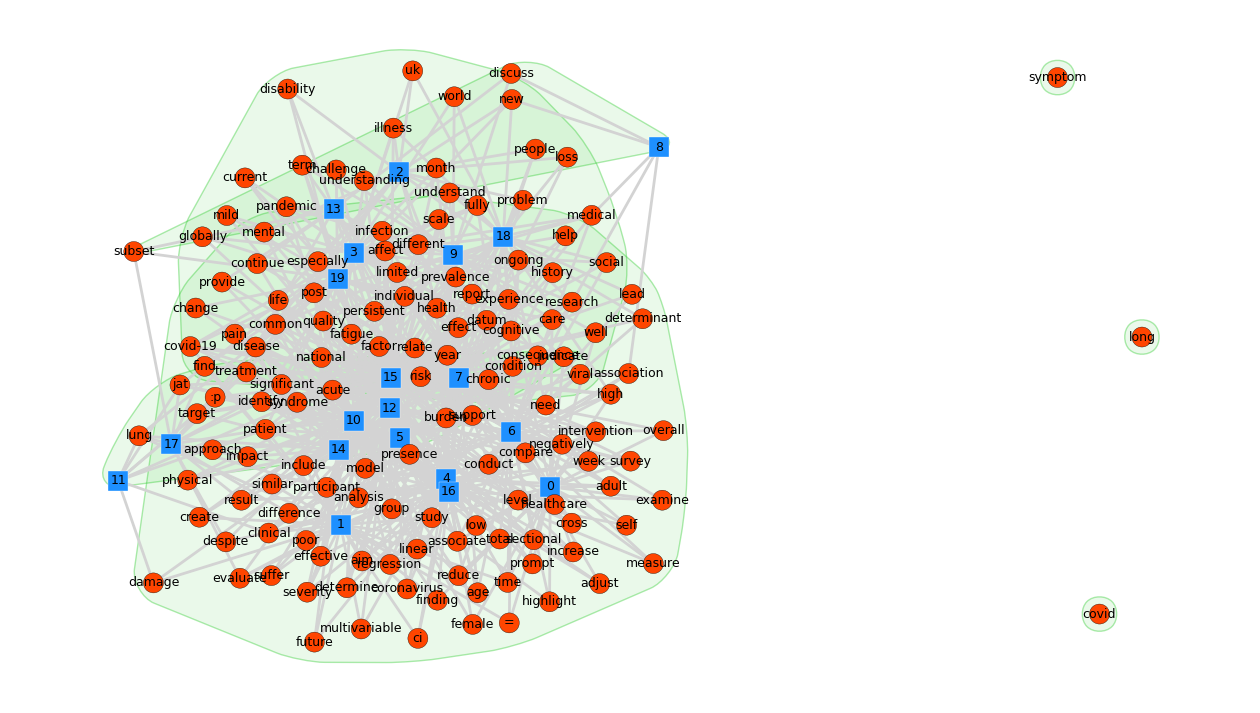

In [11]:
t.plot(label_nodes=True,
       show_clusters=True)

The text network consists of two node types, documents and terms. The document nodes represent the individual long COVID articles in the dataset (0-19 because I didn't have any other way to label them that made sense, article title would be too long), while the term nodes represent the words extracted from the abstracts. A connection exists when a term appears in a document, forming a bipartite network. This allows the network to capture how words are distributed across the articles.

Visualize again but scale the nodes according to their birank and the edges according to their weights

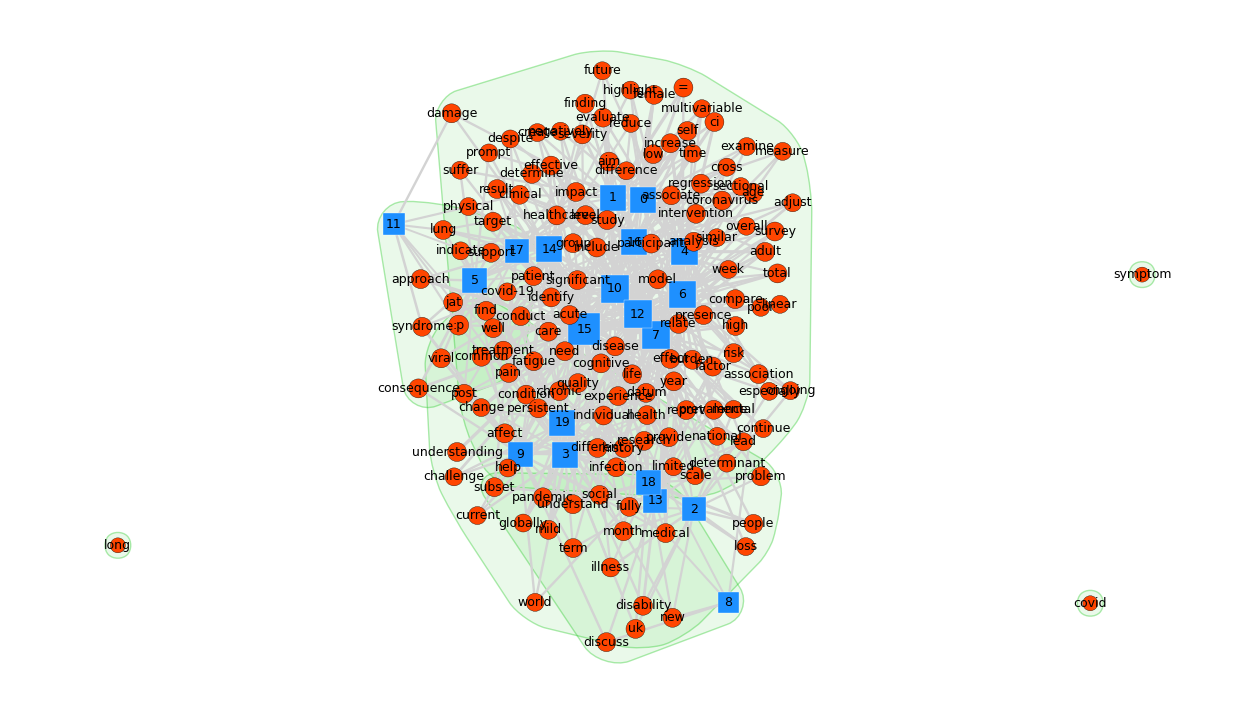

In [12]:
t.plot(label_nodes=True,
       show_clusters=True,
       scale_nodes_by="birank",
       scale_edges_by="weight")

Using the one-node term-to-term projection, clusters can be interpreted as indicating latent themes

In [13]:
terms = t.project(node_type=tn.TERM, connected=True)
terms.top_cluster_nodes()

,nodes,size
cluster,,
0,"[participant, understanding, approach, experie...",59
1,"[associate, adult, ci, age, =, model, total, s...",52
2,"[infection, cognitive, different, individual, ...",30


In my results, central terms in cluster 0 included words like participant, experience, associate, adult, and effect. These terms suggest that the dataset focuses not only on clinical aspects of long COVID, but also on participant-based research and lived experiences. The presence of terms related to statistical analysis in cluster 2, such as associate, ci, regression, model, and survey, also indicates that many of the articles rely on quantitative research methods.

Visualize projected networks

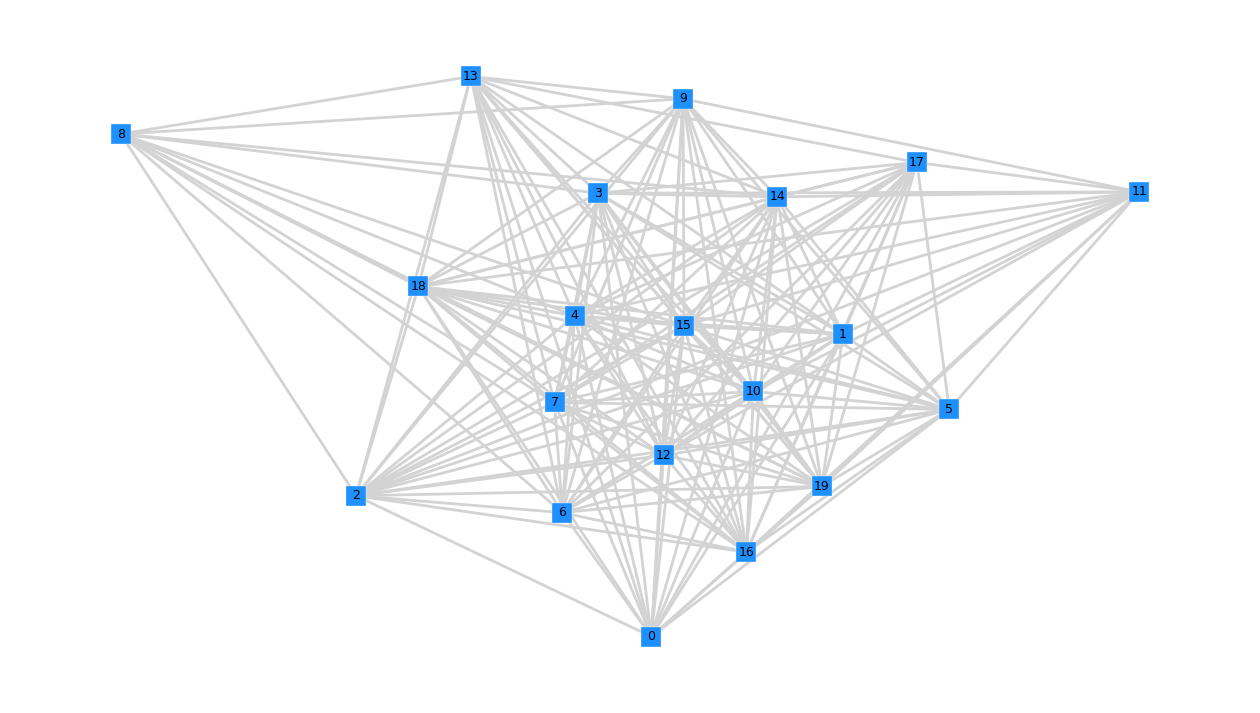

In [14]:
papers = t.project(node_type=tn.DOC)
papers.plot(label_nodes=True)

Visualizing the term network

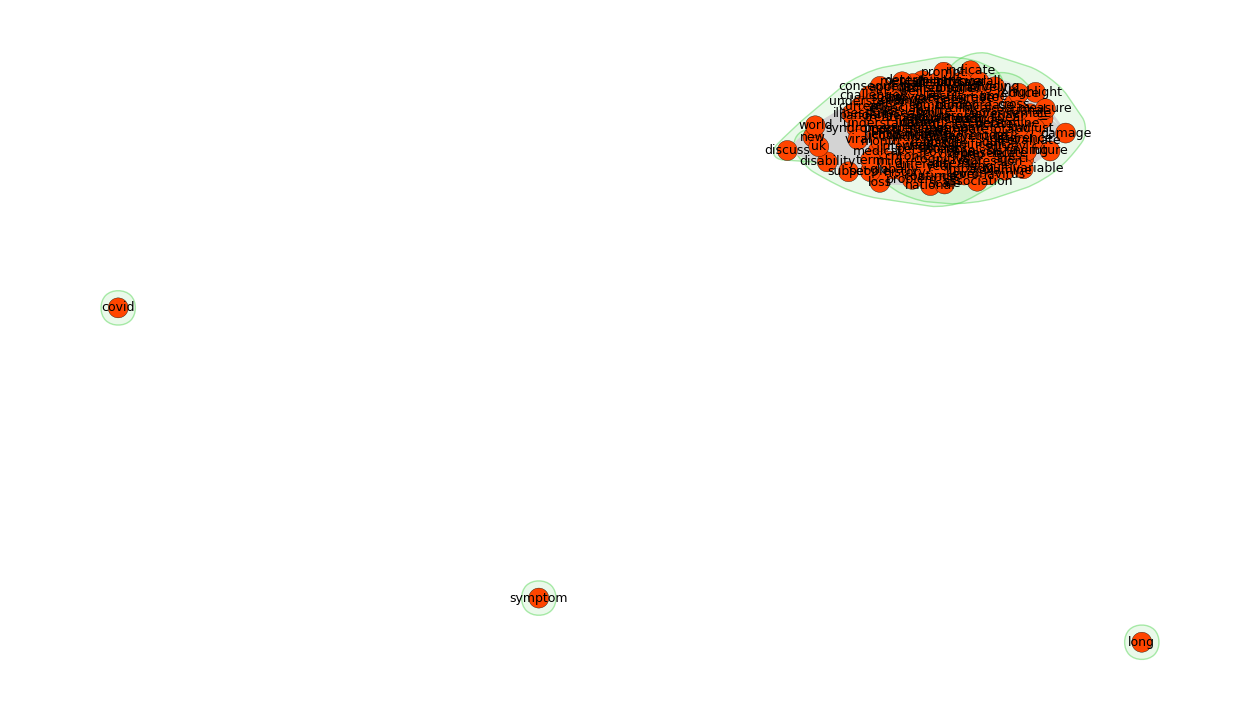

In [15]:
words = t.project(node_type=tn.TERM)
words.plot(label_nodes=True,
           show_clusters=True)

**Term-network projection:**


*   The term–term network represents patterns of co-occurrence between words in the dataset. Instead of grouping words into abstract topics, it shows how terms are directly related based on shared context. This helps reveal how meaning is constructed through relationships between terms, rather than treating words as independent features.

*   3 strongly connected term pairs in this dataset are: participant–experience, associate–adult, and effect–problem.

*   These terms are related to participant experience and research findings, which suggests that the literature frequently connects patient experiences with clinical and statistical analysis of long COVID.







In [16]:
papers.top_betweenness()

,0
15,70.0
9,7.0
4,4.0
0,0.0
3,0.0
2,0.0
1,0.0
6,0.0
7,0.0
8,0.0


In [17]:
words.top_betweenness()

,0
participant,499.0
experience,378.0
associate,236.0
adult,154.0
effect,69.0
self,58.0
find,52.0
group,52.0
well,50.5
ci,49.0


When analyzing betweenness in my results, the highest betweenness terms included participant, experience, associate, adult, effect, and self. These terms connect different clusters, suggesting they link themes. This indicates that these concepts are central to multiple discussions within the dataset.

0edges [00:00, ?edges/s]

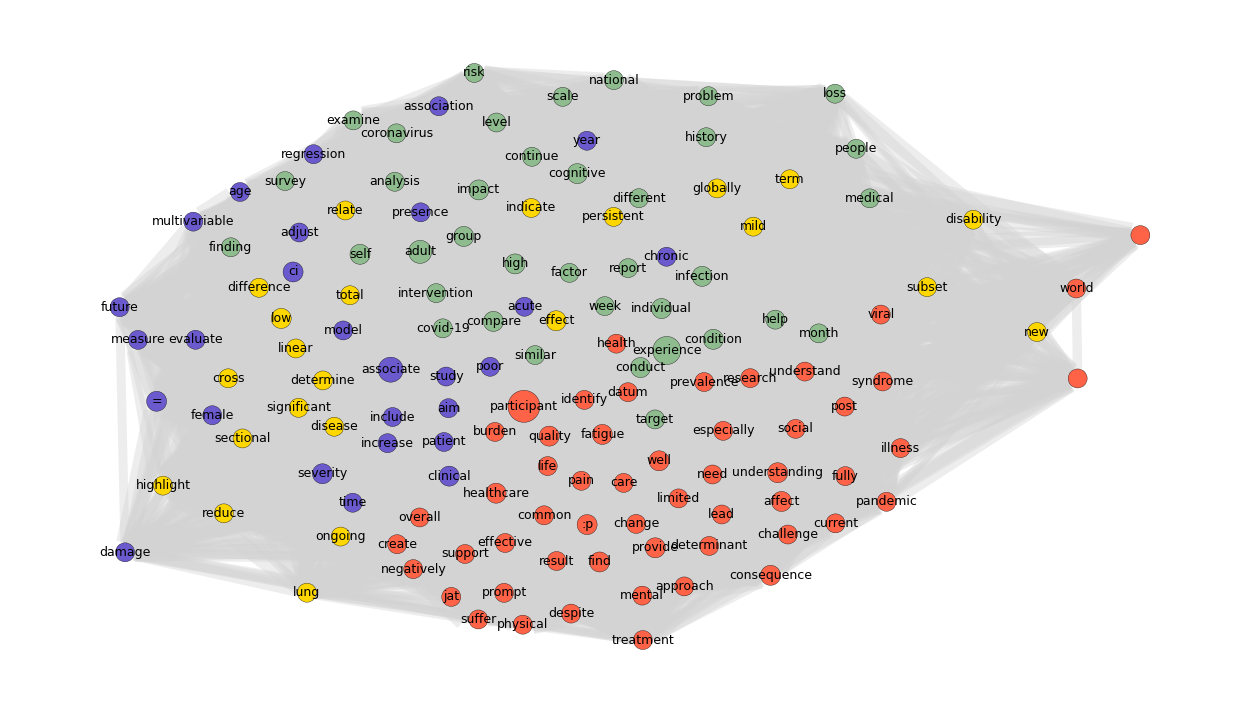

In [18]:
words.plot(label_nodes=True,
           scale_nodes_by="betweenness",
           color_clusters=True,
           alpha=0.5,
           edge_width=[10*w for w in words.edges["weight"]],
           edge_opacity=0.4,
           node_label_filter=lambda n: n.betweenness() > words.betweenness.median())

There were three clusters detected. The first cluster seems to focus on the theme of lived experience and quality of life in long covid patients, with terms like participant, experience, pain, life, and affect. The second cluster focuses on statistical research analysis, with terms such as associate, adult, ci, model, survey, and regression, which indicates a theme related to research methods and results in the study of risk factors and associations. The third cluster represents actual physical effects of long covid, with terms such as infection, cognitive, effect, and problem suggesting that this is a theme related to symptoms and long-term outcomes.

In comparison to results from lab 5, I did find similar topics and overlap between top words, such as: *clinical, cognitive, adult, associate, months*. These themes reoccurring in both TM and NTA identifies similar core themes in long covid research. I do think that the NTA visualization above provides a more in-depth and well-rounded view into these relationships in long covid research, moreso than TM. NTA doesn't group words into abstract topics like TM, it shows how terms are directly connected through co-occurrence. There are some terms present in the NTA visualization that were not included in the TM results, which suggests that the NTA approach captures a greater understanding in ideas and how they are linked.

**Reflection:**
I think the lab went well overall. I was able to run the code easily enough, but found it somewhat challenging when it came to interpretation. The first few cluster networks that we populated were so dense with terms, even after I had changed the parameters to make the networks pull in less terms and edges. It made me second guess my work. It wasn't until I got to the last chart that I could understand the clusters better and feel better about my code.

I think NTA could be useful in my future work if I decide to go into public health fields, or do more research over long covid. Because it provides a way to see how concepts are connected instead of just identifying topics, it could be helpful for analyzing how people talk about chronic health conditions, or for identifying patterns in research literature as I did in this lab.